In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
url_zip_aletas = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletas-p.zip'
url_zip_tubos2024 = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024-p.zip'
url_zip_tubos2526 = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-simil-p.zip'
url_zip_tubos2025F = '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-p.zip'

Descargamos las carpetas ZIP.

**NO VOLVER A CORRER LA SIGUIENTE CELDA**

In [5]:
import zipfile
import os

zip_paths = [url_zip_aletas, url_zip_tubos2024, url_zip_tubos2526, url_zip_tubos2025F]
extract_paths = ['/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-25simil26Proc',
                 '/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025FinalProc']

for zip_path, extract_path in zip(zip_paths, extract_paths):
  # Create destination folder if it doesn't exist
  if not os.path.exists(extract_path):
      os.makedirs(extract_path)

  # Open the zip file and extract all contents
  with zipfile.ZipFile(zip_path, 'r') as zf:
      zf.extractall(extract_path)

  print(f"DONE. {zip_path} extracted files to: {extract_path}")

DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletas-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-simil-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-25simil26Proc
DONE. /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025-p.zip extracted files to: /content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2025FinalProc


Leemos los archivos de las carpetas con los datos procesados y nos quedamos con los CSVs

In [16]:
list_csvs = []
for folder_path in extract_paths:
  name_folder = folder_path.split('/')[-1]
  print(f"--- {name_folder} ---")
  # Check if the folder exists
  if os.path.exists(folder_path) and os.path.isdir(folder_path):
      # List all files and directories in the specified path
      for filename in os.listdir(folder_path):
        if 'csv' in filename:
          file_full_path = os.path.join(folder_path, filename)
          df = pd.read_csv(file_full_path)
          df['Folder'] = name_folder
          list_csvs.append(df)
          print(file_full_path)
  else:
      print(f"Error: The folder '{folder_path}' does not exist or is not a directory.")

--- aletasProc ---
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-873_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-874_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-884_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-888_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/aletasProc/Experiment-890_stats.csv
--- tubos-2024Proc ---
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--04_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--05_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--06_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experiment-769--07_stats.csv
/content/drive/MyDrive/Rocketry ITBA/Procesamiento 3 2026/tubos-2024Proc/Experim

Armamos df

In [19]:
df = pd.concat(list_csvs, axis=0)

In [58]:
# df.to_csv('Procesamiento Marzo 2026.csv')

## Analisis Tubos

In [40]:
df.groupby('Folder').count()['sumcheck']

,sumcheck
Folder,
aletasProc,5
tubos-2024Proc,5
tubos-2025FinalProc,4
tubos-25simil26Proc,5


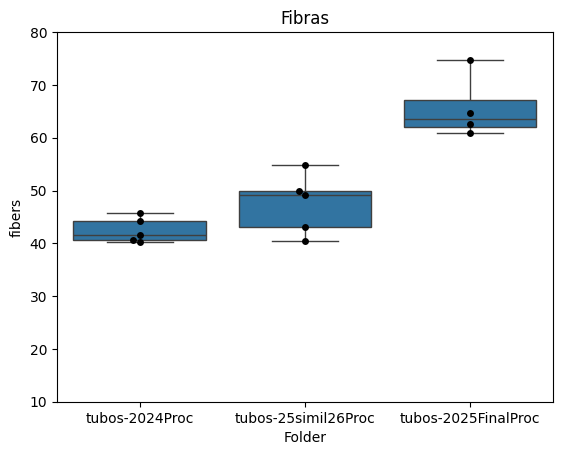

In [30]:
tubos=df[~(df['Folder'].str.contains('aletas'))]
sns.boxplot(data=tubos, x='Folder', y='fibers')
sns.swarmplot(data=tubos, x='Folder', y='fibers', color='black')
plt.ylim(10,80)
plt.title('Fibras')
plt.show()

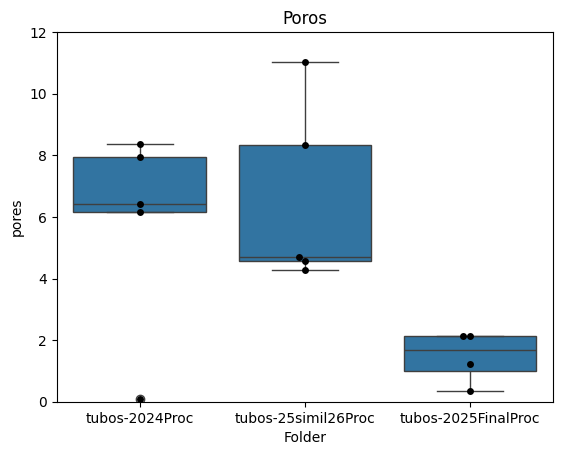

In [35]:
sns.boxplot(data=tubos, x='Folder', y='pores')
sns.swarmplot(data=tubos, x='Folder', y='pores', color='black')
plt.ylim(0,12)
plt.title('Poros')
plt.show()

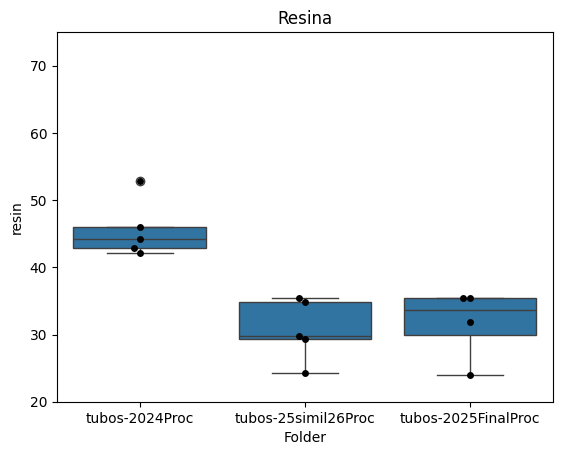

In [37]:
sns.boxplot(data=tubos, x='Folder', y='resin')
sns.swarmplot(data=tubos, x='Folder', y='resin', color='black')
plt.ylim(20,75)
plt.title('Resina')
plt.show()

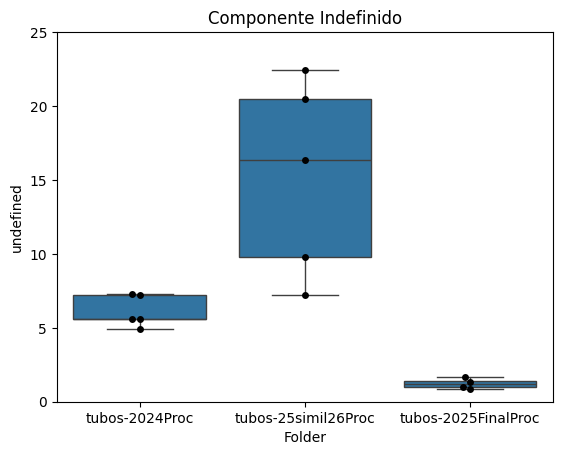

In [43]:
sns.boxplot(data=tubos, x='Folder', y='undefined')
sns.swarmplot(data=tubos, x='Folder', y='undefined', color='black')
plt.ylim(0,25)
plt.title('Componente Indefinido')
plt.show()

In [57]:
df.groupby('Folder').agg(
    fibers_Promedio=('fibers', 'mean'),
    fibers_Desvio=('fibers', 'std'),
    pores_Promedio=('pores', 'mean'),
    pores_Desvio=('pores', 'std'),
    resin_Promedio=('resin', 'mean'),
    resin_Desvio=('resin', 'std'),
    undefined_Promedio=('undefined', 'mean'),
    undefined_Desvio=('undefined', 'std')
)

,fibers_Promedio,fibers_Desvio,pores_Promedio,pores_Desvio,resin_Promedio,resin_Desvio,undefined_Promedio,undefined_Desvio
Folder,,,,,,,,
aletasProc,56.723150,10.176779,14.162416,8.227008,27.446872,10.276947,1.667562,0.561402
tubos-2024Proc,42.469288,2.455025,5.800740,3.339254,45.601666,4.279338,6.128306,1.050353
tubos-2025FinalProc,65.680269,6.193632,1.454651,0.860955,31.649936,5.376505,1.215145,0.364188
tubos-25simil26Proc,47.470683,5.764272,6.585015,2.995223,30.703490,4.563489,15.240811,6.612824


## Analisis Aletas

Alerta: algunas micrografias no son muy buenas

In [59]:
aletas = df[df['Folder'].str.contains('aletas')]
aletas

,file,param_otsu_classes,param_otsu_range,param_first_kernel_size,param_second_kernel_size,param_contours_mult,param_bh_ks,param_bhm_iter,param_bhm_mult,param_cont_mult,param_ws_ths_factor,param_ws_gl_vecinity,pores,fibers,resin,undefined,sumcheck,Folder
0,Experiment-873,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,8.117611,51.344501,38.734622,1.803265,100.0,aletasProc
0,Experiment-874,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,21.444695,56.318477,20.563131,1.673697,100.0,aletasProc
0,Experiment-884,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.031431,65.477850,13.853553,1.637166,100.0,aletasProc
0,Experiment-888,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,19.440184,42.906315,35.255818,2.397684,100.0,aletasProc
0,Experiment-890,5,"(3, 4)","(5, 5)","(3, 3)",2.5,"(7, 7)",4,60,2.5,0.025,15,2.778161,67.568609,28.827234,0.825996,100.0,aletasProc


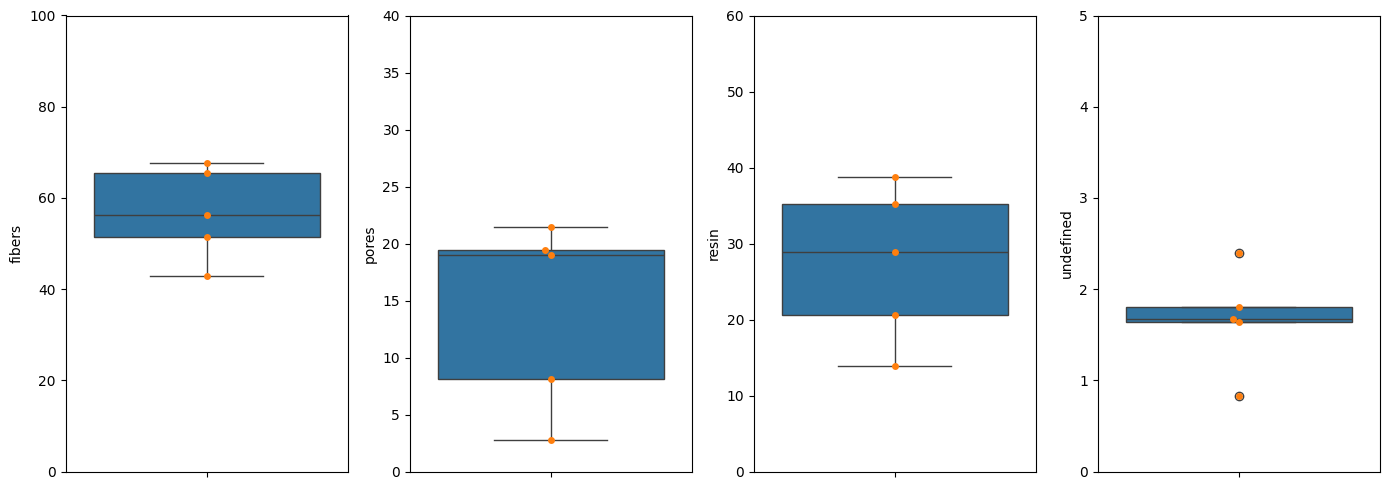

In [76]:
fig, axs = plt.subplots(figsize=(14,5), nrows=1, ncols=4)
sns.boxplot(data=aletas, y='fibers', ax=axs[0])
sns.swarmplot(data=aletas, y='fibers', ax=axs[0])
axs[0].set_ylim(0,100)

sns.boxplot(data=aletas, y='pores', ax=axs[1])
sns.swarmplot(data=aletas, y='pores', ax=axs[1])
axs[1].set_ylim(0,40)

sns.boxplot(data=aletas, y='resin', ax=axs[2])
sns.swarmplot(data=aletas, y='resin', ax=axs[2])
axs[2].set_ylim(0,60)

sns.boxplot(data=aletas, y='undefined', ax=axs[3])
sns.swarmplot(data=aletas, y='undefined', ax=axs[3])
axs[3].set_ylim(0,5)

plt.tight_layout()
plt.show()